**CUSTOMER SEGMENTATION**

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df = pd.read_csv('/content/Mall_Customers.csv')
print(df.head(10))
print(df.info())
print(df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Custom

In [29]:
df = df.drop(['CustomerID'], axis=1)

In [30]:
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0}).astype(int)

In [31]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [32]:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_df.describe().round(2))

       Gender     Age  Annual Income (k$)  Spending Score (1-100)
count  200.00  200.00              200.00                  200.00
mean    -0.00   -0.00               -0.00                   -0.00
std      1.00    1.00                1.00                    1.00
min     -1.13   -1.50               -1.74                   -1.91
25%     -1.13   -0.72               -0.73                   -0.60
50%      0.89   -0.20                0.04                   -0.01
75%      0.89    0.73                0.67                    0.89
max      0.89    2.24                2.92                    1.89


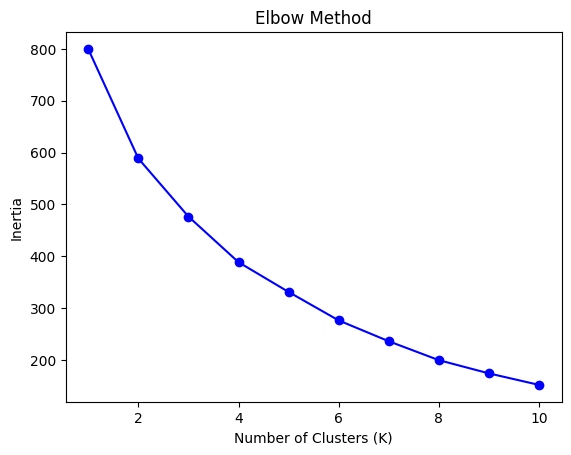

In [33]:
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [34]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(scaled_data)

# add cluster labels back to original dataframe
df['Cluster'] = kmeans.labels_
print(df['Cluster'].value_counts())

Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64


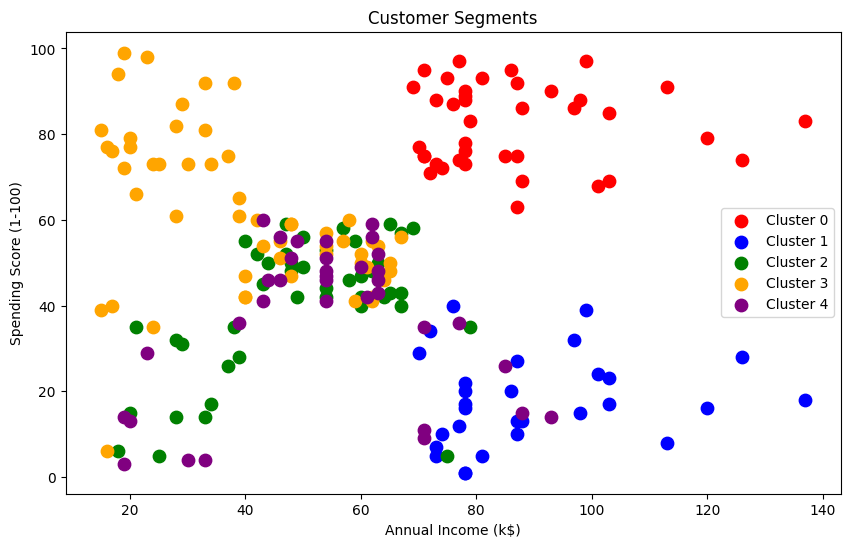

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', s=80)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()
plt.show()

In [36]:
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        32.7                86.5                    82.1
1        36.5                89.5                    18.0
2        49.8                49.2                    40.1
3        24.9                39.7                    61.2
4        55.7                53.7                    36.8
